In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import warnings
warnings.filterwarnings('ignore')

# Set random seed for reproducibility (IMPORTANT in production)
np.random.seed(42)

In [2]:
# Load the breast cancer dataset
# This is a real medical dataset with 30 features
data = load_breast_cancer()
X = data.data  # Features
y = data.target  # Target (0=malignant, 1=benign)

# Create DataFrame for better visualization
df = pd.DataFrame(X, columns=data.feature_names)
df['target'] = y

print(f"\nDataset Shape: {X.shape}")
print(f"Number of samples: {X.shape[0]}")
print(f"Number of features: {X.shape[1]}")
print(f"Number of classes: {len(np.unique(y))}")
print(f"Class distribution:\n{pd.Series(y).value_counts()}")


Dataset Shape: (569, 30)
Number of samples: 569
Number of features: 30
Number of classes: 2
Class distribution:
1    357
0    212
Name: count, dtype: int64


In [4]:
# Display first few rows
print(f"\nFirst 5 rows of data:")
df.head()



First 5 rows of data:


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,0
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,0


In [5]:
# Basic statistics
print(f"\nBasic Statistics:")
print(df.describe())


Basic Statistics:
       mean radius  mean texture  mean perimeter    mean area  \
count   569.000000    569.000000      569.000000   569.000000   
mean     14.127292     19.289649       91.969033   654.889104   
std       3.524049      4.301036       24.298981   351.914129   
min       6.981000      9.710000       43.790000   143.500000   
25%      11.700000     16.170000       75.170000   420.300000   
50%      13.370000     18.840000       86.240000   551.100000   
75%      15.780000     21.800000      104.100000   782.700000   
max      28.110000     39.280000      188.500000  2501.000000   

       mean smoothness  mean compactness  mean concavity  mean concave points  \
count       569.000000        569.000000      569.000000           569.000000   
mean          0.096360          0.104341        0.088799             0.048919   
std           0.014064          0.052813        0.079720             0.038803   
min           0.052630          0.019380        0.000000             0.

In [6]:
# 3.1 Split data into train and test sets (ALWAYS do this BEFORE scaling)
# Why? To prevent data leakage from test set
X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.2,  # 80% train, 20% test
    random_state=42,  # For reproducibility
    stratify=y  # Maintain class distribution in both sets
)

In [7]:
print(f"Training set size: {X_train.shape[0]} samples")
print(f"Test set size: {X_test.shape[0]} samples")

Training set size: 455 samples
Test set size: 114 samples


In [8]:
scaler = StandardScaler()

# Fit scaler on training data ONLY (prevent data leakage)
scaler.fit(X_train)

# Transform both train and test data
X_train_scaled = scaler.transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [9]:
print(f"\nBefore scaling - Sample feature means:")
print(f"Feature 0 mean: {X_train[:, 0].mean():.2f}")
print(f"Feature 1 mean: {X_train[:, 1].mean():.2f}")

print(f"\nAfter scaling - Sample feature means (should be ~0):")
print(f"Feature 0 mean: {X_train_scaled[:, 0].mean():.4f}")
print(f"Feature 1 mean: {X_train_scaled[:, 1].mean():.4f}")

print(f"\nBefore scaling - Sample feature std devs (should be ~1):")
print(f"Feature 0 std: {X_train[:, 0].std():.4f}")
print(f"Feature 1 std: {X_train[:, 1].std():.4f}")

print(f"\nAfter scaling - Sample feature std devs (should be ~1):")
print(f"Feature 0 std: {X_train_scaled[:, 0].std():.4f}")
print(f"Feature 1 std: {X_train_scaled[:, 1].std():.4f}")


Before scaling - Sample feature means:
Feature 0 mean: 14.07
Feature 1 mean: 19.25

After scaling - Sample feature means (should be ~0):
Feature 0 mean: -0.0000
Feature 1 mean: 0.0000

Before scaling - Sample feature std devs (should be ~1):
Feature 0 std: 3.4955
Feature 1 std: 4.4004

After scaling - Sample feature std devs (should be ~1):
Feature 0 std: 1.0000
Feature 1 std: 1.0000


In [10]:
# Fit PCA with all components to see variance explained
pca_full = PCA()
pca_full.fit(X_train_scaled)

,n_components,None
,copy,True
,whiten,False
,svd_solver,'auto'
,tol,0.0
,iterated_power,'auto'
,n_oversamples,10
,power_iteration_normalizer,'auto'
,random_state,None


In [11]:
pca_full.explained_variance_ratio_

array([4.44134918e-01, 1.89446183e-01, 9.54335633e-02, 6.72468941e-02,
       5.51769040e-02, 3.93453424e-02, 2.18176591e-02, 1.58331722e-02,
       1.27878330e-02, 1.14544250e-02, 9.26269214e-03, 8.47428916e-03,
       7.99746679e-03, 5.30706257e-03, 3.12250212e-03, 2.57146110e-03,
       2.03925720e-03, 1.86696858e-03, 1.49100638e-03, 1.03671459e-03,
       9.25703045e-04, 8.66421035e-04, 7.19778970e-04, 5.88332657e-04,
       5.04652748e-04, 2.45507775e-04, 2.16103111e-04, 5.71732867e-05,
       2.57352579e-05, 4.27774949e-06])

In [12]:
# Calculate cumulative variance explained
cumulative_variance = np.cumsum(pca_full.explained_variance_ratio_)

In [13]:
cumulative_variance

array([0.44413492, 0.6335811 , 0.72901466, 0.79626156, 0.85143846,
       0.8907838 , 0.91260146, 0.92843464, 0.94122247, 0.95267689,
       0.96193959, 0.97041388, 0.97841134, 0.9837184 , 0.98684091,
       0.98941237, 0.99145162, 0.99331859, 0.9948096 , 0.99584631,
       0.99677202, 0.99763844, 0.99835822, 0.99894655, 0.9994512 ,
       0.99969671, 0.99991281, 0.99996999, 0.99999572, 1.        ])

In [15]:
print(f"\nVariance explained by each component (first 10):")
for i in range(min(30, len(pca_full.explained_variance_ratio_))):
    print(f"PC{i+1}: {pca_full.explained_variance_ratio_[i]*100:.2f}%")


Variance explained by each component (first 10):
PC1: 44.41%
PC2: 18.94%
PC3: 9.54%
PC4: 6.72%
PC5: 5.52%
PC6: 3.93%
PC7: 2.18%
PC8: 1.58%
PC9: 1.28%
PC10: 1.15%
PC11: 0.93%
PC12: 0.85%
PC13: 0.80%
PC14: 0.53%
PC15: 0.31%
PC16: 0.26%
PC17: 0.20%
PC18: 0.19%
PC19: 0.15%
PC20: 0.10%
PC21: 0.09%
PC22: 0.09%
PC23: 0.07%
PC24: 0.06%
PC25: 0.05%
PC26: 0.02%
PC27: 0.02%
PC28: 0.01%
PC29: 0.00%
PC30: 0.00%


In [16]:
print(f"\nCumulative variance explained:")
print(f"First 5 components: {cumulative_variance[4]*100:.2f}%")
print(f"First 10 components: {cumulative_variance[9]*100:.2f}%")
print(f"First 15 components: {cumulative_variance[14]*100:.2f}%")


Cumulative variance explained:
First 5 components: 85.14%
First 10 components: 95.27%
First 15 components: 98.68%


In [17]:
# Industry rule of thumb: Keep components that explain 95% variance
n_components_95 = np.argmax(cumulative_variance >= 0.95) + 1
print(f"\nComponents needed for 95% variance: {n_components_95}")


Components needed for 95% variance: 10


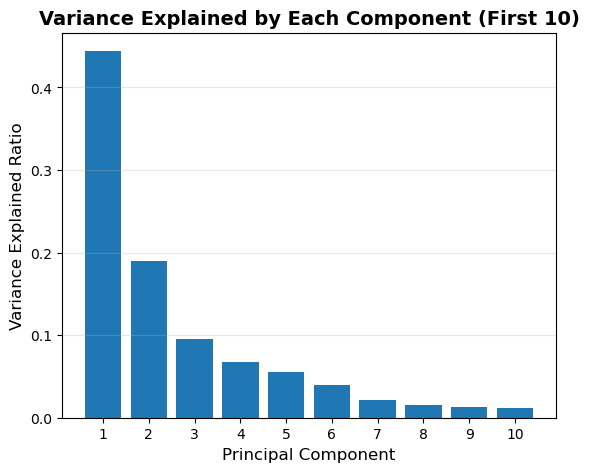

In [18]:
# Visualize variance explained (Industry best practice)
plt.figure(figsize=(14, 5))

# Plot 1: Individual variance
plt.subplot(1, 2, 1)
plt.bar(range(1, 11), pca_full.explained_variance_ratio_[:10])
plt.xlabel('Principal Component', fontsize=12)
plt.ylabel('Variance Explained Ratio', fontsize=12)
plt.title('Variance Explained by Each Component (First 10)', fontsize=14, fontweight='bold')
plt.xticks(range(1, 11))
plt.grid(axis='y', alpha=0.3)

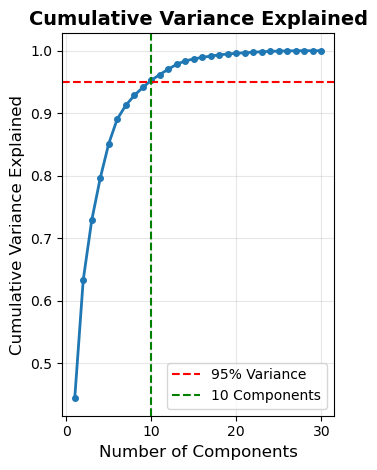

In [19]:
# Plot 2: Cumulative variance
plt.subplot(1, 2, 2)
plt.plot(range(1, len(cumulative_variance)+1), cumulative_variance, 
         marker='o', linewidth=2, markersize=4)
plt.axhline(y=0.95, color='r', linestyle='--', label='95% Variance')
plt.axvline(x=n_components_95, color='g', linestyle='--', 
            label=f'{n_components_95} Components')
plt.xlabel('Number of Components', fontsize=12)
plt.ylabel('Cumulative Variance Explained', fontsize=12)
plt.title('Cumulative Variance Explained', fontsize=14, fontweight='bold')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
#plt.savefig('pca_variance_explained.png', dpi=300, bbox_inches='tight')
#print("\n✓ Saved: pca_variance_explained.png")

In [20]:
# Decision: Use components that explain 95% variance
n_components = n_components_95

# Initialize PCA
pca = PCA(n_components=n_components, random_state=42)

# Fit PCA on training data ONLY
pca.fit(X_train_scaled)

# Transform both training and test data
X_train_pca = pca.transform(X_train_scaled)
X_test_pca = pca.transform(X_test_scaled)

print(f"\nOriginal feature space: {X_train_scaled.shape[1]} dimensions")
print(f"Reduced feature space: {X_train_pca.shape[1]} dimensions")
print(f"Dimensionality reduction: {(1 - n_components/X_train_scaled.shape[1])*100:.1f}%")
print(f"Variance retained: {cumulative_variance[n_components-1]*100:.2f}%")



Original feature space: 30 dimensions
Reduced feature space: 10 dimensions
Dimensionality reduction: 66.7%
Variance retained: 95.27%


In [21]:
# Display principal component weights (first PC only)
print(f"\nTop 5 features contributing to PC1:")
pc1_weights = np.abs(pca.components_[0])
top_5_idx = np.argsort(pc1_weights)[-5:][::-1]
for idx in top_5_idx:
    print(f"  {data.feature_names[idx]}: {pc1_weights[idx]:.4f}")


Top 5 features contributing to PC1:
  mean concave points: 0.2614
  mean concavity: 0.2578
  worst concave points: 0.2499
  mean compactness: 0.2422
  worst perimeter: 0.2349


In [22]:
# Create 2D PCA for visualization
pca_2d = PCA(n_components=2, random_state=42)
X_train_pca_2d = pca_2d.fit_transform(X_train_scaled)
X_test_pca_2d = pca_2d.transform(X_test_scaled)

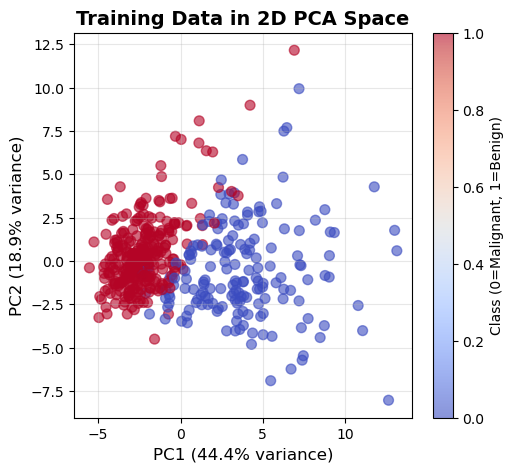

In [23]:
# Plot
plt.figure(figsize=(12, 5))

# Training data
plt.subplot(1, 2, 1)
scatter_train = plt.scatter(X_train_pca_2d[:, 0], X_train_pca_2d[:, 1], 
                            c=y_train, cmap='coolwarm', alpha=0.6, s=50)
plt.xlabel(f'PC1 ({pca_2d.explained_variance_ratio_[0]*100:.1f}% variance)', 
           fontsize=12)
plt.ylabel(f'PC2 ({pca_2d.explained_variance_ratio_[1]*100:.1f}% variance)', 
           fontsize=12)
plt.title('Training Data in 2D PCA Space', fontsize=14, fontweight='bold')
plt.colorbar(scatter_train, label='Class (0=Malignant, 1=Benign)')
plt.grid(True, alpha=0.3)

In [24]:
# Model 1: Random Forest on ORIGINAL features
print("\n--- Model 1: Original Features (30 dimensions) ---")
clf_original = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
clf_original.fit(X_train_scaled, y_train)
y_pred_original = clf_original.predict(X_test_scaled)
accuracy_original = accuracy_score(y_test, y_pred_original)

print(f"Training time: Fast")
print(f"Test Accuracy: {accuracy_original*100:.2f}%")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_original, 
                          target_names=['Malignant', 'Benign']))

# Model 2: Random Forest on PCA features
print("\n--- Model 2: PCA Features ({} dimensions) ---".format(n_components))
clf_pca = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
clf_pca.fit(X_train_pca, y_train)
y_pred_pca = clf_pca.predict(X_test_pca)
accuracy_pca = accuracy_score(y_test, y_pred_pca)

print(f"Training time: Faster (fewer features)")
print(f"Test Accuracy: {accuracy_pca*100:.2f}%")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_pca, 
                          target_names=['Malignant', 'Benign']))



--- Model 1: Original Features (30 dimensions) ---
Training time: Fast
Test Accuracy: 95.61%

Classification Report:
              precision    recall  f1-score   support

   Malignant       0.95      0.93      0.94        42
      Benign       0.96      0.97      0.97        72

    accuracy                           0.96       114
   macro avg       0.96      0.95      0.95       114
weighted avg       0.96      0.96      0.96       114


--- Model 2: PCA Features (10 dimensions) ---
Training time: Faster (fewer features)
Test Accuracy: 92.11%

Classification Report:
              precision    recall  f1-score   support

   Malignant       0.88      0.90      0.89        42
      Benign       0.94      0.93      0.94        72

    accuracy                           0.92       114
   macro avg       0.91      0.92      0.92       114
weighted avg       0.92      0.92      0.92       114



In [25]:
# Comparison
print("\n" + "="*80)
print("COMPARISON SUMMARY")
print("="*80)
print(f"\n{'Metric':<30} {'Original':<15} {'PCA':<15}")
print("-" * 60)
print(f"{'Number of Features':<30} {X_train_scaled.shape[1]:<15} {n_components:<15}")
print(f"{'Test Accuracy':<30} {accuracy_original*100:.2f}%{' '*9} {accuracy_pca*100:.2f}%")
print(f"{'Dimensionality Reduction':<30} {'-':<15} {(1-n_components/30)*100:.1f}%")
print(f"{'Training Speed':<30} {'Baseline':<15} {'Faster':<15}")
print(f"{'Model Size':<30} {'Larger':<15} {'Smaller':<15}")

accuracy_diff = (accuracy_pca - accuracy_original) * 100
print(f"\nAccuracy difference: {accuracy_diff:+.2f}%")

if abs(accuracy_diff) < 2:
    print("✓ PCA maintains accuracy with significantly fewer features!")
elif accuracy_diff > 0:
    print("✓ PCA even improved accuracy (removed noise)!")
else:
    print("⚠ PCA slightly reduced accuracy (may need more components)")


COMPARISON SUMMARY

Metric                         Original        PCA            
------------------------------------------------------------
Number of Features             30              10             
Test Accuracy                  95.61%          92.11%
Dimensionality Reduction       -               66.7%
Training Speed                 Baseline        Faster         
Model Size                     Larger          Smaller        

Accuracy difference: -3.51%
⚠ PCA slightly reduced accuracy (may need more components)
